# 🏦 Havi — EDA Unificado

**Proyecto:** datamoles — DSC x Hey 2026  
**Autor:** Diego Quiros (DQ)  
**Propósito:** Carga, validación e inspección inicial de los 4 datasets del datathon Hey Banco.  
Este notebook es la base de referencia para todos los UCs. Corre esto primero antes de cualquier feature engineering.

---

## 0. Setup & Imports

Importamos todas las librerías, configuramos opciones de display y definimos las rutas a los datasets como constantes.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import time

# Suprimir warnings para output limpio
warnings.filterwarnings('ignore')

# Estilo visual unificado
sns.set_theme(style='whitegrid')

# Opciones de display
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)
pd.set_option('display.max_rows', 100)

print('Librerías cargadas correctamente.')
print(f'  pandas  : {pd.__version__}')
print(f'  numpy   : {np.__version__}')

Librerías cargadas correctamente.
  pandas  : 3.0.2
  numpy   : 2.4.4


In [3]:
# ── Rutas a los datasets (ajustar si es necesario) ──────────────────────────
DATA_PATH = {
    'clientes'      : '/Users/diegodq/Downloads/dataton/dataset_transacciones/hey_clientes.csv',
    'productos'     : '/Users/diegodq/Downloads/dataton/dataset_transacciones/hey_productos.csv',
    'transacciones' : '/Users/diegodq/Downloads/dataton/dataset_transacciones/hey_transacciones.csv',
    'conversaciones': '/Users/diegodq/Downloads/dataton/dataset_conversaciones/dataset_50k_anonymized.parquet',
}

for k, v in DATA_PATH.items():
    print(f'  {k:<15} → {v}')

  clientes        → /Users/diegodq/Downloads/dataton/dataset_transacciones/hey_clientes.csv
  productos       → /Users/diegodq/Downloads/dataton/dataset_transacciones/hey_productos.csv
  transacciones   → /Users/diegodq/Downloads/dataton/dataset_transacciones/hey_transacciones.csv
  conversaciones  → /Users/diegodq/Downloads/dataton/dataset_conversaciones/dataset_50k_anonymized.parquet


---

## 1. Carga de Datasets

Cargamos los 4 datasets e imprimimos el shape de cada uno para tener una idea inicial del volumen de datos.

| Dataset | Descripción |
|---|---|
| `hey_clientes.csv` | Demografía y señales de comportamiento por usuario. Join key: `user_id` |
| `hey_productos.csv` | Portfolio de productos contratados por usuario. Join key: `user_id` |
| `hey_transacciones.csv` | Historial transaccional completo. Join key: `user_id` |
| `dataset_50k_anonymized.parquet` | 49,999 conversaciones entre usuarios y Havi. Join key: `user_id` |

In [4]:
%%time
# Carga de hey_clientes.csv
df_clientes = pd.read_csv(DATA_PATH['clientes'])
print(f'df_clientes      → {df_clientes.shape[0]:>8,} filas  x  {df_clientes.shape[1]:>3} columnas')

df_clientes      →   15,025 filas  x   22 columnas
CPU times: user 30.7 ms, sys: 8.94 ms, total: 39.7 ms
Wall time: 42.9 ms


In [5]:
%%time
# Carga de hey_productos.csv
df_productos = pd.read_csv(DATA_PATH['productos'])
print(f'df_productos     → {df_productos.shape[0]:>8,} filas  x  {df_productos.shape[1]:>3} columnas')

df_productos     →   38,909 filas  x   13 columnas
CPU times: user 29.1 ms, sys: 4.37 ms, total: 33.5 ms
Wall time: 33.9 ms


In [6]:
%%time
# Carga de hey_transacciones.csv (dataset más pesado)
df_transacciones = pd.read_csv(DATA_PATH['transacciones'])
print(f'df_transacciones → {df_transacciones.shape[0]:>8,} filas  x  {df_transacciones.shape[1]:>3} columnas')

df_transacciones →  802,384 filas  x   22 columnas
CPU times: user 1.22 s, sys: 84.3 ms, total: 1.3 s
Wall time: 1.33 s


In [7]:
%%time
# Carga del dataset de conversaciones (formato parquet)
df_conversaciones = pd.read_parquet(DATA_PATH['conversaciones'])
print(f'df_conversaciones→ {df_conversaciones.shape[0]:>8,} filas  x  {df_conversaciones.shape[1]:>3} columnas')

df_conversaciones→   49,999 filas  x    6 columnas
CPU times: user 206 ms, sys: 61.8 ms, total: 268 ms
Wall time: 2.03 s


---

## 2. Inspección Rápida

Para cada dataset: primeras filas, tipos de datos, y estadísticas descriptivas.

### 2.1 Clientes

In [8]:
# Primeras 5 filas
df_clientes.head(5)

,user_id,edad,sexo,estado,ciudad,nivel_educativo,ocupacion,ingreso_mensual_mxn,antiguedad_dias,es_hey_pro,nomina_domiciliada,canal_apertura,score_buro,dias_desde_ultimo_login,preferencia_canal,satisfaccion_1_10,recibe_remesas,usa_hey_shop,idioma_preferido,tiene_seguro,num_productos_activos,patron_uso_atipico
0,USR-00001,21,M,Ciudad de México,CDMX - Benito Juárez,Preparatoria,Empleado,24500,1554,True,False,App,527,1,app_android,10.00,False,True,es_MX,False,2,False
1,USR-00002,18,M,Jalisco,Puerto Vallarta,Preparatoria,Estudiante,19000,1410,True,False,App,714,3,app_android,8.00,False,True,es_MX,True,2,False
2,USR-00003,23,H,Chihuahua,Cuauhtémoc,Licenciatura,Estudiante,14000,1174,True,False,App,454,3,app_ios,8.00,False,True,es_MX,False,2,False
3,USR-00004,32,SE,Nuevo León,Guadalupe,Posgrado,Empleado,61000,1168,False,False,Fan Shop,837,16,app_ios,10.00,True,False,es_MX,True,3,False
4,USR-00005,26,M,Ciudad de México,CDMX - Cuauhtémoc,Preparatoria,Empresario,27000,816,True,False,Fan Shop,533,1,app_ios,7.00,False,True,es_MX,True,2,False


In [9]:
# Tipos de datos y valores no-nulos por columna
df_clientes.info()

<class 'pandas.DataFrame'>
RangeIndex: 15025 entries, 0 to 15024
Data columns (total 22 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   user_id                  15025 non-null  str    
 1   edad                     15025 non-null  int64  
 2   sexo                     15025 non-null  str    
 3   estado                   14593 non-null  str    
 4   ciudad                   14593 non-null  str    
 5   nivel_educativo          15025 non-null  str    
 6   ocupacion                15025 non-null  str    
 7   ingreso_mensual_mxn      15025 non-null  int64  
 8   antiguedad_dias          15025 non-null  int64  
 9   es_hey_pro               15025 non-null  bool   
 10  nomina_domiciliada       15025 non-null  bool   
 11  canal_apertura           15025 non-null  str    
 12  score_buro               15025 non-null  int64  
 13  dias_desde_ultimo_login  15025 non-null  int64  
 14  preferencia_canal        15025 no

In [10]:
# Estadísticas descriptivas (numéricas y categóricas)
df_clientes.describe(include='all')

,user_id,edad,sexo,estado,ciudad,nivel_educativo,ocupacion,ingreso_mensual_mxn,antiguedad_dias,es_hey_pro,nomina_domiciliada,canal_apertura,score_buro,dias_desde_ultimo_login,preferencia_canal,satisfaccion_1_10,recibe_remesas,usa_hey_shop,idioma_preferido,tiene_seguro,num_productos_activos,patron_uso_atipico
count,15025,15025.00,15025,14593,14593,15025,15025,15025.00,15025.00,15025,15025,15025,15025.00,15025.00,15025,14274.00,15025,15025,15025,15025,15025.00,15025
unique,15025,NaN,3,17,83,4,6,NaN,NaN,2,2,2,NaN,NaN,3,NaN,2,2,2,2,NaN,2
top,USR-00001,NaN,M,Ciudad de México,CDMX - Tlalpan,Licenciatura,Empleado,NaN,NaN,False,False,App,NaN,NaN,app_ios,NaN,False,False,es_MX,False,NaN,False
freq,1,NaN,7281,2627,538,6616,8550,NaN,NaN,7680,9897,12189,NaN,NaN,6641,NaN,13774,10768,14544,10883,NaN,14262
mean,NaN,37.19,NaN,NaN,NaN,NaN,NaN,29793.68,935.11,NaN,NaN,NaN,618.45,18.77,NaN,7.48,NaN,NaN,NaN,NaN,2.23,NaN
std,NaN,10.19,NaN,NaN,NaN,NaN,NaN,19171.16,512.96,NaN,NaN,NaN,127.16,35.31,NaN,1.88,NaN,NaN,NaN,NaN,1.14,NaN
min,NaN,18.00,NaN,NaN,NaN,NaN,NaN,4500.00,7.00,NaN,NaN,NaN,295.00,0.00,NaN,3.00,NaN,NaN,NaN,NaN,0.00,NaN
25%,NaN,29.00,NaN,NaN,NaN,NaN,NaN,16000.00,490.00,NaN,NaN,NaN,529.00,2.00,NaN,6.00,NaN,NaN,NaN,NaN,1.00,NaN
50%,NaN,36.00,NaN,NaN,NaN,NaN,NaN,24000.00,942.00,NaN,NaN,NaN,631.00,7.00,NaN,8.00,NaN,NaN,NaN,NaN,2.00,NaN
75%,NaN,45.00,NaN,NaN,NaN,NaN,NaN,37000.00,1375.00,NaN,NaN,NaN,719.00,15.00,NaN,9.00,NaN,NaN,NaN,NaN,3.00,NaN


### 2.2 Productos

In [11]:
df_productos.head(5)

,producto_id,user_id,tipo_producto,fecha_apertura,estatus,limite_credito,saldo_actual,utilizacion_pct,tasa_interes_anual,plazo_meses,monto_mensualidad,fecha_ultimo_movimiento,es_dato_sintetico
0,PRD-00000001,USR-00001,cuenta_debito,2023-06-26,activo,NaN,80954.60,NaN,NaN,NaN,NaN,2025-11-27,True
1,PRD-00000002,USR-00001,tarjeta_credito_hey,2022-10-16,activo,144000.00,88790.40,0.62,35.71,NaN,NaN,2025-09-17,True
2,PRD-00000003,USR-00002,cuenta_debito,2025-04-03,activo,NaN,20712.54,NaN,NaN,NaN,NaN,2025-10-16,True
3,PRD-00000004,USR-00002,tarjeta_credito_hey,2025-07-18,activo,22000.00,6122.60,0.28,34.08,NaN,NaN,2025-09-15,True
4,PRD-00000005,USR-00003,cuenta_debito,2023-03-26,activo,NaN,3454.65,NaN,NaN,NaN,NaN,2025-09-27,True


In [12]:
df_productos.info()

<class 'pandas.DataFrame'>
RangeIndex: 38909 entries, 0 to 38908
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   producto_id              38909 non-null  str    
 1   user_id                  38909 non-null  str    
 2   tipo_producto            38909 non-null  str    
 3   fecha_apertura           38909 non-null  str    
 4   estatus                  38909 non-null  str    
 5   limite_credito           14317 non-null  float64
 6   saldo_actual             35159 non-null  float64
 7   utilizacion_pct          14317 non-null  float64
 8   tasa_interes_anual       18791 non-null  float64
 9   plazo_meses              4550 non-null   float64
 10  monto_mensualidad        4550 non-null   float64
 11  fecha_ultimo_movimiento  38909 non-null  str    
 12  es_dato_sintetico        38909 non-null  bool   
dtypes: bool(1), float64(6), str(6)
memory usage: 5.9 MB


In [13]:
df_productos.describe(include='all')

,producto_id,user_id,tipo_producto,fecha_apertura,estatus,limite_credito,saldo_actual,utilizacion_pct,tasa_interes_anual,plazo_meses,monto_mensualidad,fecha_ultimo_movimiento,es_dato_sintetico
count,38909,38909,38909,38909,38909,14317.00,35159.00,14317.00,18791.00,4550.00,4550.00,38909,38909
unique,38909,15025,11,1733,4,NaN,NaN,NaN,NaN,NaN,NaN,91,1
top,PRD-00000001,USR-00024,cuenta_debito,2025-11-15,activo,NaN,NaN,NaN,NaN,NaN,NaN,2025-09-08,True
freq,1,5,15025,104,33548,NaN,NaN,NaN,NaN,NaN,NaN,470,38909
mean,NaN,NaN,NaN,NaN,NaN,89630.93,60007.06,0.43,29.12,23.07,1990.70,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,94668.50,84090.73,0.25,15.48,13.75,1683.13,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,1000.00,100.94,0.05,3.50,6.00,36.29,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,29000.00,15596.24,0.24,14.66,12.00,738.24,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,64000.00,36290.09,0.37,31.74,18.00,1477.32,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,111000.00,66193.26,0.58,41.06,24.00,2784.11,NaN,NaN


### 2.3 Transacciones

In [14]:
df_transacciones.head(5)

,transaccion_id,user_id,producto_id,fecha_hora,tipo_operacion,canal,monto,comercio_nombre,categoria_mcc,ciudad_transaccion,estatus,motivo_no_procesada,intento_numero,meses_diferidos,cashback_generado,descripcion_libre,hora_del_dia,dia_semana,es_internacional,dispositivo,patron_uso_atipico,es_dato_sintetico
0,TXN-0000000055,USR-00001,PRD-00000002,2025-01-15 14:17:42,compra,app_ios,33.88,DivertidoPark,entretenimiento,"Nueva York, NY",completada,NaN,1,NaN,0.34,Cargo automático,14,Wednesday,True,app_ios,False,True
1,TXN-0000000048,USR-00001,PRD-00000001,2025-01-17 00:31:56,cargo_recurrente,app_ios,249.00,GamerPass,servicios_digitales,CDMX - Benito Juárez,completada,NaN,1,NaN,NaN,Cargo automático,0,Friday,False,app_ios,False,True
2,TXN-0000000018,USR-00001,PRD-00000001,2025-01-17 22:48:23,cargo_recurrente,app_huawei,399.00,CloudDrive MX,servicios_digitales,CDMX - Benito Juárez,completada,NaN,1,NaN,NaN,inv hey,22,Friday,False,app_huawei,False,True
3,TXN-0000000043,USR-00001,PRD-00000001,2025-01-19 11:10:43,transf_salida,app_android,8910.00,NaN,transferencia,CDMX - Benito Juárez,completada,NaN,1,NaN,NaN,SPEI enviado,11,Sunday,False,app_android,False,True
4,TXN-0000000009,USR-00001,PRD-00000001,2025-02-15 07:03:50,compra,app_ios,568.59,QuickBite MX,restaurante,CDMX - Benito Juárez,completada,NaN,1,NaN,5.69,dep. efvo,7,Saturday,False,app_ios,False,True


In [15]:
df_transacciones.info()

<class 'pandas.DataFrame'>
RangeIndex: 802384 entries, 0 to 802383
Data columns (total 22 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   transaccion_id       802384 non-null  str    
 1   user_id              802384 non-null  str    
 2   producto_id          802384 non-null  str    
 3   fecha_hora           802384 non-null  str    
 4   tipo_operacion       802384 non-null  str    
 5   canal                802384 non-null  str    
 6   monto                802384 non-null  float64
 7   comercio_nombre      431846 non-null  str    
 8   categoria_mcc        802384 non-null  str    
 9   ciudad_transaccion   783117 non-null  str    
 10  estatus              802384 non-null  str    
 11  motivo_no_procesada  26609 non-null   str    
 12  intento_numero       802384 non-null  int64  
 13  meses_diferidos      17313 non-null   float64
 14  cashback_generado    180638 non-null  float64
 15  descripcion_libre    740632 

In [16]:
df_transacciones.describe(include='all')

,transaccion_id,user_id,producto_id,fecha_hora,tipo_operacion,canal,monto,comercio_nombre,categoria_mcc,ciudad_transaccion,estatus,motivo_no_procesada,intento_numero,meses_diferidos,cashback_generado,descripcion_libre,hora_del_dia,dia_semana,es_internacional,dispositivo,patron_uso_atipico,es_dato_sintetico
count,802384,802384,802384,802384,802384,802384,802384.00,431846,802384,783117,802384,26609,802384.00,17313.00,180638.00,740632,802384.00,802384,802384,600321,802384,802384
unique,802213,15025,29972,789602,12,9,NaN,75,14,93,4,8,NaN,NaN,NaN,36,NaN,7,2,3,2,1
top,TXN-0000003652,USR-05378,PRD-00001342,2025-03-01 10:28:02,compra,app_ios,NaN,PodcastHub,transferencia,CDMX - Tlalpan,completada,monto_excede_limite_diario,NaN,NaN,NaN,ret. cajero,NaN,Saturday,False,app_ios,False,True
freq,2,101,100,4,319524,268313,NaN,15483,367049,26173,748267,3366,NaN,NaN,NaN,20839,NaN,117543,762369,268313,760892,802384
mean,NaN,NaN,NaN,NaN,NaN,NaN,6108.50,NaN,NaN,NaN,NaN,NaN,1.03,10.78,14.79,NaN,11.44,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,9885.31,NaN,NaN,NaN,NaN,NaN,0.23,7.20,24.63,NaN,6.76,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,5.01,NaN,NaN,NaN,NaN,NaN,1.00,3.00,0.12,NaN,0.00,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,540.00,NaN,NaN,NaN,NaN,NaN,1.00,6.00,3.56,NaN,6.00,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,1740.00,NaN,NaN,NaN,NaN,NaN,1.00,9.00,6.93,NaN,11.00,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,7030.94,NaN,NaN,NaN,NaN,NaN,1.00,12.00,17.24,NaN,17.00,NaN,NaN,NaN,NaN,NaN


### 2.4 Conversaciones

In [17]:
df_conversaciones.head(5)

,input,output,date,conv_id,user_id,channel_source
0,"Me enteré de una promo ""Supercashback Pagos Gu...",Claro que puedo ayudarte! Para participar en l...,2025-08-17,000502c2-288c-41f6-b751-a8b45a376a81,USR-09092,1
1,La tarjeta de crédito Hey Negocios es diferent...,Claro! La Tarjeta de Crédito Hey Negocios es d...,2025-08-17,000502c2-288c-41f6-b751-a8b45a376a81,USR-09092,1
2,"Entiendo, gracias",¡De nada! Me alegra haber podido ayudarte. Si ...,2025-08-17,000502c2-288c-41f6-b751-a8b45a376a81,USR-09092,1
3,Hola,¡Hola! ¿Cómo estás? Estoy aquí para ayudarte c...,2025-09-16,00221607-cdb2-47f2-a9ac-913d4c7744c6,USR-09344,1
4,Verificación de cuenta,Claro que puedo ayudarte con eso. Para validar...,2025-09-16,00221607-cdb2-47f2-a9ac-913d4c7744c6,USR-09344,1


In [18]:
df_conversaciones.info()

<class 'pandas.DataFrame'>
RangeIndex: 49999 entries, 0 to 49998
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   input           49999 non-null  str  
 1   output          49999 non-null  str  
 2   date            49999 non-null  str  
 3   conv_id         49999 non-null  str  
 4   user_id         49999 non-null  str  
 5   channel_source  49999 non-null  str  
dtypes: str(6)
memory usage: 30.6 MB


In [19]:
df_conversaciones.describe(include='all')

,input,output,date,conv_id,user_id,channel_source
count,49999,49999,49999,49999,49999,49999
unique,41889,45307,3213,24119,15025,2
top,Si,¡Hola! ¿Cómo estás? Estoy aquí para ayudarte c...,2025-10-01,7662250a-309b-4fe9-9664-206b78540015,USR-04234,1
freq,867,346,649,21,75,46936


---

## 3. Calidad de Datos

Análisis de nulos, duplicados y consistencia general por dataset.  
El helper `check_data_quality()` genera un resumen estandarizado.

In [20]:
def check_data_quality(df: pd.DataFrame, name: str) -> pd.DataFrame:
    """
    Imprime un resumen de calidad de datos para el DataFrame dado.
    Retorna un DataFrame con el detalle de nulos por columna.
    """
    print(f'{'='*55}')
    print(f'  Dataset : {name}')
    print(f'  Shape   : {df.shape[0]:,} filas x {df.shape[1]} columnas')
    print(f'  Dupes   : {df.duplicated().sum():,} filas duplicadas')
    print(f'{'='*55}')

    # Tabla de nulos ordenada de mayor a menor
    null_counts = df.isnull().sum()
    null_pct    = (null_counts / len(df) * 100).round(2)
    null_df = pd.DataFrame({
        'nulls'  : null_counts,
        'pct_%'  : null_pct,
        'dtype'  : df.dtypes
    }).sort_values('nulls', ascending=False)

    # Solo mostrar columnas con al menos 1 nulo
    null_df_filtered = null_df[null_df['nulls'] > 0]
    if null_df_filtered.empty:
        print('  ✓ Sin valores nulos en ninguna columna.')
    else:
        print(f'  Columnas con nulos ({len(null_df_filtered)}/{len(df.columns)}):')
        print(null_df_filtered.to_string())
    print()
    return null_df

In [21]:
# ── Calidad: Clientes ────────────────────────────────────────────────────────
null_clientes = check_data_quality(df_clientes, 'hey_clientes')

  Dataset : hey_clientes
  Shape   : 15,025 filas x 22 columnas
  Dupes   : 0 filas duplicadas
  Columnas con nulos (3/22):
                   nulls  pct_%    dtype
satisfaccion_1_10    751   5.00  float64
estado               432   2.88      str
ciudad               432   2.88      str



In [22]:
# Detalle completo de nulos en clientes (todas las columnas)
null_clientes

,nulls,pct_%,dtype
satisfaccion_1_10,751,5.00,float64
estado,432,2.88,str
ciudad,432,2.88,str
user_id,0,0.00,str
score_buro,0,0.00,int64
num_productos_activos,0,0.00,int64
tiene_seguro,0,0.00,bool
idioma_preferido,0,0.00,str
usa_hey_shop,0,0.00,bool
recibe_remesas,0,0.00,bool


In [23]:
# ── Calidad: Productos ───────────────────────────────────────────────────────
null_productos = check_data_quality(df_productos, 'hey_productos')

  Dataset : hey_productos
  Shape   : 38,909 filas x 13 columnas
  Dupes   : 0 filas duplicadas
  Columnas con nulos (6/13):
                    nulls  pct_%    dtype
plazo_meses         34359  88.31  float64
monto_mensualidad   34359  88.31  float64
limite_credito      24592  63.20  float64
utilizacion_pct     24592  63.20  float64
tasa_interes_anual  20118  51.71  float64
saldo_actual         3750   9.64  float64



In [24]:
null_productos

,nulls,pct_%,dtype
plazo_meses,34359,88.31,float64
monto_mensualidad,34359,88.31,float64
limite_credito,24592,63.20,float64
utilizacion_pct,24592,63.20,float64
tasa_interes_anual,20118,51.71,float64
saldo_actual,3750,9.64,float64
producto_id,0,0.00,str
user_id,0,0.00,str
tipo_producto,0,0.00,str
fecha_apertura,0,0.00,str


In [25]:
# ── Calidad: Transacciones ───────────────────────────────────────────────────
null_transacciones = check_data_quality(df_transacciones, 'hey_transacciones')

  Dataset : hey_transacciones
  Shape   : 802,384 filas x 22 columnas
  Dupes   : 0 filas duplicadas
  Columnas con nulos (7/22):
                      nulls  pct_%    dtype
meses_diferidos      785071  97.84  float64
motivo_no_procesada  775775  96.68      str
cashback_generado    621746  77.49  float64
comercio_nombre      370538  46.18      str
dispositivo          202063  25.18      str
descripcion_libre     61752   7.70      str
ciudad_transaccion    19267   2.40      str



In [26]:
null_transacciones

,nulls,pct_%,dtype
meses_diferidos,785071,97.84,float64
motivo_no_procesada,775775,96.68,str
cashback_generado,621746,77.49,float64
comercio_nombre,370538,46.18,str
dispositivo,202063,25.18,str
descripcion_libre,61752,7.70,str
ciudad_transaccion,19267,2.40,str
intento_numero,0,0.00,int64
patron_uso_atipico,0,0.00,bool
es_internacional,0,0.00,bool


In [27]:
# ── Calidad: Conversaciones ──────────────────────────────────────────────────
null_conversaciones = check_data_quality(df_conversaciones, 'dataset_50k')

  Dataset : dataset_50k
  Shape   : 49,999 filas x 6 columnas
  Dupes   : 18 filas duplicadas
  ✓ Sin valores nulos en ninguna columna.



In [28]:
null_conversaciones

,nulls,pct_%,dtype
input,0,0.00,str
output,0,0.00,str
date,0,0.00,str
conv_id,0,0.00,str
user_id,0,0.00,str
channel_source,0,0.00,str


---

## 4. Análisis de Join Keys

Validamos la presencia y unicidad de `user_id` en cada dataset.  
Todos los datasets se unen por `user_id` — es crítico entender el overlap entre ellos antes de hacer cualquier join.

In [29]:
# ── Verificar que user_id existe en todos los datasets ──────────────────────
datasets = {
    'clientes'      : df_clientes,
    'productos'     : df_productos,
    'transacciones' : df_transacciones,
    'conversaciones': df_conversaciones,
}

for name, df in datasets.items():
    has_uid = 'user_id' in df.columns
    status  = '✓' if has_uid else '✗ MISSING'
    print(f'  {name:<15} user_id presente: {status}')

  clientes        user_id presente: ✓
  productos       user_id presente: ✓
  transacciones   user_id presente: ✓
  conversaciones  user_id presente: ✓


In [30]:
# ── Cardinalidad de user_id por dataset ─────────────────────────────────────
print(f'{'Dataset':<20} {'Total filas':>12} {'Users únicos':>14} {'Es único (1:1)?':>16}')
print('-' * 65)
for name, df in datasets.items():
    if 'user_id' not in df.columns:
        continue
    total_rows   = len(df)
    unique_users = df['user_id'].nunique()
    is_unique    = '✓ Sí' if total_rows == unique_users else f'✗ No ({total_rows/unique_users:.1f}x)'
    print(f'  {name:<18} {total_rows:>12,} {unique_users:>14,} {is_unique:>16}')

Dataset               Total filas   Users únicos  Es único (1:1)?
-----------------------------------------------------------------
  clientes                 15,025         15,025             ✓ Sí
  productos                38,909         15,025      ✗ No (2.6x)
  transacciones           802,384         15,025     ✗ No (53.4x)
  conversaciones           49,999         15,025      ✗ No (3.3x)


In [31]:
# ── Intersección de user_ids entre datasets ──────────────────────────────────
users_clientes       = set(df_clientes['user_id'])       if 'user_id' in df_clientes.columns       else set()
users_productos      = set(df_productos['user_id'])      if 'user_id' in df_productos.columns      else set()
users_transacciones  = set(df_transacciones['user_id'])  if 'user_id' in df_transacciones.columns  else set()
users_conversaciones = set(df_conversaciones['user_id']) if 'user_id' in df_conversaciones.columns else set()

# Intersecciones pairwise
cli_x_txn  = users_clientes & users_transacciones
cli_x_prod = users_clientes & users_productos
cli_x_conv = users_clientes & users_conversaciones
txn_x_conv = users_transacciones & users_conversaciones

# Intersección de todos
all_four   = users_clientes & users_productos & users_transacciones & users_conversaciones

print('── Intersecciones de user_id ──────────────────────────────')
print(f'  clientes  ∩ transacciones  : {len(cli_x_txn):>7,}')
print(f'  clientes  ∩ productos      : {len(cli_x_prod):>7,}')
print(f'  clientes  ∩ conversaciones : {len(cli_x_conv):>7,}')
print(f'  transacc. ∩ conversaciones : {len(txn_x_conv):>7,}')
print(f'  Los 4 datasets juntos      : {len(all_four):>7,}')

── Intersecciones de user_id ──────────────────────────────
  clientes  ∩ transacciones  :  15,025
  clientes  ∩ productos      :  15,025
  clientes  ∩ conversaciones :  15,025
  transacc. ∩ conversaciones :  15,025
  Los 4 datasets juntos      :  15,025


In [32]:
# ── Usuarios en conversaciones pero NO en transacciones (relevante para UC4) ─
conv_sin_txn = users_conversaciones - users_transacciones
txn_sin_conv = users_transacciones  - users_conversaciones

print(f'  Usuarios en conv. SIN transacciones : {len(conv_sin_txn):,}')
print(f'  Usuarios en txn.  SIN conversaciones: {len(txn_sin_conv):,}')

# % de cobertura cruzada
if len(users_conversaciones) > 0:
    pct = len(txn_x_conv) / len(users_conversaciones) * 100
    print(f'  Cobertura transaccional en conv.    : {pct:.1f}%')

  Usuarios en conv. SIN transacciones : 0
  Usuarios en txn.  SIN conversaciones: 0
  Cobertura transaccional en conv.    : 100.0%


---

## 5. Distribuciones Básicas

Visualizaciones de las distribuciones más relevantes por dataset.

### 5.1 Clientes

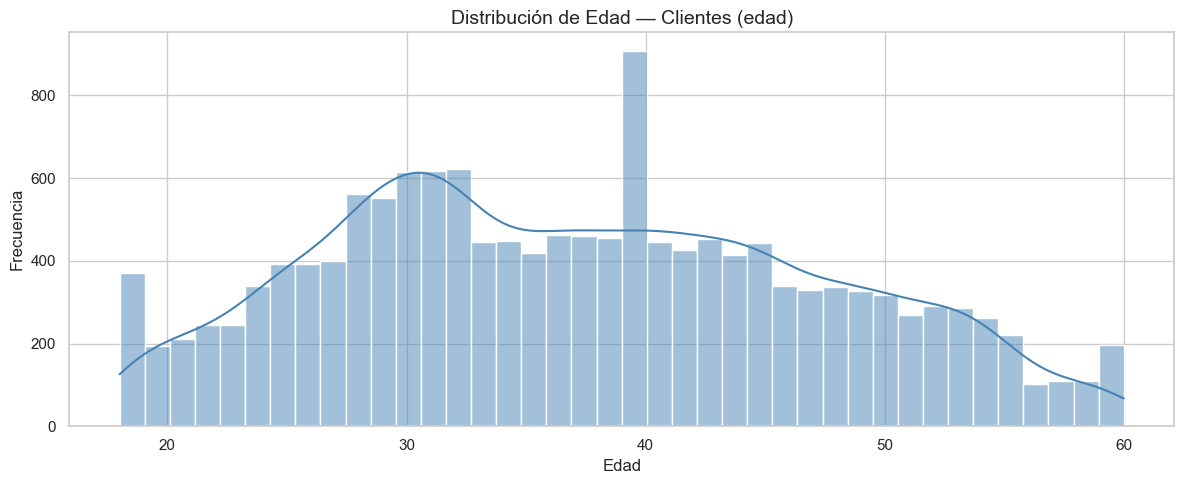

In [33]:
# ── Distribución de edad ─────────────────────────────────────────────────────
# Buscar columna de edad (puede llamarse 'edad', 'age', etc.)
age_col = next((c for c in df_clientes.columns if 'edad' in c.lower() or 'age' in c.lower()), None)

if age_col:
    fig, ax = plt.subplots(figsize=(12, 5))
    sns.histplot(df_clientes[age_col].dropna(), bins=40, kde=True, ax=ax, color='steelblue')
    ax.set_title(f'Distribución de Edad — Clientes ({age_col})', fontsize=14)
    ax.set_xlabel('Edad')
    ax.set_ylabel('Frecuencia')
    plt.tight_layout()
    plt.show()
else:
    print(f'No se encontró columna de edad. Columnas disponibles: {list(df_clientes.columns)}')

In [34]:
# ── Distribución por segmento ────────────────────────────────────────────────
# Buscar columna de segmento
seg_col = next((c for c in df_clientes.columns if 'segmento' in c.lower() or 'segment' in c.lower()), None)

if seg_col:
    seg_counts = df_clientes[seg_col].value_counts()
    fig, ax = plt.subplots(figsize=(12, 5))
    sns.barplot(x=seg_counts.index.astype(str), y=seg_counts.values, ax=ax, palette='viridis')
    ax.set_title(f'Distribución por Segmento — Clientes ({seg_col})', fontsize=14)
    ax.set_xlabel('Segmento')
    ax.set_ylabel('Cantidad de usuarios')
    plt.tight_layout()
    plt.show()
else:
    print(f'No se encontró columna de segmento. Columnas: {list(df_clientes.columns)}')

No se encontró columna de segmento. Columnas: ['user_id', 'edad', 'sexo', 'estado', 'ciudad', 'nivel_educativo', 'ocupacion', 'ingreso_mensual_mxn', 'antiguedad_dias', 'es_hey_pro', 'nomina_domiciliada', 'canal_apertura', 'score_buro', 'dias_desde_ultimo_login', 'preferencia_canal', 'satisfaccion_1_10', 'recibe_remesas', 'usa_hey_shop', 'idioma_preferido', 'tiene_seguro', 'num_productos_activos', 'patron_uso_atipico']


### 5.2 Productos

In [ ]:
# ── Distribución por tipo de producto ────────────────────────────────────────
prod_col = next((c for c in df_productos.columns if 'tipo' in c.lower() or 'product' in c.lower() or 'type' in c.lower()), None)

if prod_col:
    prod_counts = df_productos[prod_col].value_counts()
    fig, ax = plt.subplots(figsize=(12, 5))
    sns.barplot(x=prod_counts.index.astype(str), y=prod_counts.values, ax=ax, palette='magma')
    ax.set_title(f'Distribución por Tipo de Producto ({prod_col})', fontsize=14)
    ax.set_xlabel('Tipo de Producto')
    ax.set_ylabel('Cantidad')
    ax.tick_params(axis='x', rotation=30)
    plt.tight_layout()
    plt.show()
else:
    print(f'No se encontró columna de tipo de producto. Columnas: {list(df_productos.columns)}')

In [ ]:
# ── Histograma: productos por usuario ────────────────────────────────────────
if 'user_id' in df_productos.columns:
    prods_per_user = df_productos.groupby('user_id').size()
    fig, ax = plt.subplots(figsize=(12, 5))
    sns.histplot(prods_per_user, bins=30, kde=False, ax=ax, color='coral')
    ax.set_title('Cantidad de Productos por Usuario', fontsize=14)
    ax.set_xlabel('Número de productos')
    ax.set_ylabel('Cantidad de usuarios')
    plt.tight_layout()
    plt.show()
    print(prods_per_user.describe())

### 5.3 Transacciones

In [ ]:
# ── Distribución de montos (con opción log scale) ────────────────────────────
amt_col = next((c for c in df_transacciones.columns if 'monto' in c.lower() or 'amount' in c.lower() or 'importe' in c.lower()), None)

if amt_col:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Escala normal
    sns.histplot(df_transacciones[amt_col].dropna(), bins=50, ax=axes[0], color='teal')
    axes[0].set_title(f'Monto — escala normal ({amt_col})')
    axes[0].set_xlabel('Monto')

    # Escala log (filtramos montos > 0)
    pos_amounts = df_transacciones[df_transacciones[amt_col] > 0][amt_col]
    sns.histplot(np.log10(pos_amounts + 1), bins=50, ax=axes[1], color='teal')
    axes[1].set_title(f'Monto — escala log10 ({amt_col})')
    axes[1].set_xlabel('log10(Monto + 1)')

    plt.tight_layout()
    plt.show()
else:
    print(f'No se encontró columna de monto. Columnas: {list(df_transacciones.columns)}')

In [ ]:
# ── Distribución por tipo de transacción ─────────────────────────────────────
tipo_col = next((c for c in df_transacciones.columns if 'tipo' in c.lower() or 'type' in c.lower()), None)

if tipo_col:
    tipo_counts = df_transacciones[tipo_col].value_counts()
    fig, ax = plt.subplots(figsize=(12, 5))
    sns.barplot(x=tipo_counts.index.astype(str), y=tipo_counts.values, ax=ax, palette='coolwarm')
    ax.set_title(f'Distribución por Tipo de Transacción ({tipo_col})', fontsize=14)
    ax.set_xlabel('Tipo')
    ax.set_ylabel('Cantidad')
    ax.tick_params(axis='x', rotation=30)
    plt.tight_layout()
    plt.show()
else:
    print(f'No se encontró columna de tipo. Columnas: {list(df_transacciones.columns)}')

In [ ]:
# ── Volumen mensual de transacciones ─────────────────────────────────────────
# Buscar columna de fecha
date_col = next((c for c in df_transacciones.columns if 'fecha' in c.lower() or 'date' in c.lower()), None)

if date_col:
    # Convertir a datetime si no lo es
    df_transacciones[date_col] = pd.to_datetime(df_transacciones[date_col], errors='coerce')
    monthly_vol = df_transacciones.groupby(df_transacciones[date_col].dt.to_period('M')).size()
    monthly_vol.index = monthly_vol.index.astype(str)

    fig, ax = plt.subplots(figsize=(14, 5))
    ax.plot(monthly_vol.index, monthly_vol.values, marker='o', linewidth=2, color='darkblue')
    ax.fill_between(range(len(monthly_vol)), monthly_vol.values, alpha=0.15, color='steelblue')
    ax.set_xticks(range(len(monthly_vol)))
    ax.set_xticklabels(monthly_vol.index, rotation=45, ha='right')
    ax.set_title('Volumen Mensual de Transacciones', fontsize=14)
    ax.set_xlabel('Mes')
    ax.set_ylabel('Número de transacciones')
    plt.tight_layout()
    plt.show()
else:
    print(f'No se encontró columna de fecha. Columnas: {list(df_transacciones.columns)}')

### 5.4 Conversaciones

In [ ]:
# ── Distribución por channel_source (1=texto, 2=voz) ─────────────────────────
if 'channel_source' in df_conversaciones.columns:
    ch_map    = {1: 'Texto', 2: 'Voz'}
    ch_counts = df_conversaciones['channel_source'].map(ch_map).value_counts()

    fig, ax = plt.subplots(figsize=(8, 5))
    sns.barplot(x=ch_counts.index, y=ch_counts.values, ax=ax, palette=['#2196F3', '#FF9800'])
    ax.set_title('Canal de Conversación (channel_source)', fontsize=14)
    ax.set_xlabel('Canal')
    ax.set_ylabel('Cantidad de registros')
    for i, v in enumerate(ch_counts.values):
        ax.text(i, v + v*0.01, f'{v:,}', ha='center', fontsize=11)
    plt.tight_layout()
    plt.show()
else:
    print(f'Columna channel_source no encontrada. Columnas: {list(df_conversaciones.columns)}')

In [ ]:
# ── Conversaciones por usuario ────────────────────────────────────────────────
if 'user_id' in df_conversaciones.columns:
    conv_id_col = next((c for c in df_conversaciones.columns if 'conv_id' in c.lower()), None)
    if conv_id_col:
        convs_per_user = df_conversaciones.groupby('user_id')[conv_id_col].nunique()
    else:
        convs_per_user = df_conversaciones.groupby('user_id').size()

    fig, ax = plt.subplots(figsize=(12, 5))
    sns.histplot(convs_per_user, bins=40, kde=True, ax=ax, color='purple')
    ax.set_title('Conversaciones por Usuario', fontsize=14)
    ax.set_xlabel('Número de conversaciones')
    ax.set_ylabel('Cantidad de usuarios')
    plt.tight_layout()
    plt.show()
    print(convs_per_user.describe())

In [ ]:
# ── Turnos por conversación ───────────────────────────────────────────────────
conv_id_col = next((c for c in df_conversaciones.columns if 'conv_id' in c.lower()), None)
turn_col    = next((c for c in df_conversaciones.columns if 'turn' in c.lower() or 'turno' in c.lower()), None)

if conv_id_col:
    turns_per_conv = df_conversaciones.groupby(conv_id_col).size()
    fig, ax = plt.subplots(figsize=(12, 5))
    sns.histplot(turns_per_conv, bins=40, kde=True, ax=ax, color='darkorange')
    ax.set_title('Turnos por Conversación', fontsize=14)
    ax.set_xlabel('Número de turnos')
    ax.set_ylabel('Cantidad de conversaciones')
    plt.tight_layout()
    plt.show()
    print(turns_per_conv.describe())
else:
    print(f'No se encontró columna conv_id. Columnas: {list(df_conversaciones.columns)}')

---

## 6. Correlaciones Cruzadas (Cross-Dataset)

¿Qué porcentaje de los usuarios del dataset de conversaciones también tiene datos transaccionales?  
Esta pregunta es crítica para **UC4**: si el overlap es bajo, el análisis cruzado de intent vs comportamiento transaccional tendrá menos cobertura.

In [ ]:
# ── Cobertura cruzada conversaciones ↔ otros datasets ────────────────────────
if 'user_id' in df_conversaciones.columns:
    total_conv_users = len(users_conversaciones)

    cov_txn  = len(users_conversaciones & users_transacciones)
    cov_prod = len(users_conversaciones & users_productos)
    cov_cli  = len(users_conversaciones & users_clientes)

    coverage = {
        'conv ∩ clientes'      : cov_cli,
        'conv ∩ productos'     : cov_prod,
        'conv ∩ transacciones' : cov_txn,
    }

    fig, ax = plt.subplots(figsize=(10, 5))
    labels = list(coverage.keys())
    values = list(coverage.values())
    pcts   = [v / total_conv_users * 100 for v in values]

    bars = ax.barh(labels, pcts, color=['#4CAF50', '#2196F3', '#FF5722'])
    ax.set_xlim(0, 110)
    for bar, pct, cnt in zip(bars, pcts, values):
        ax.text(pct + 1, bar.get_y() + bar.get_height()/2,
                f'{pct:.1f}%  ({cnt:,} users)', va='center', fontsize=11)
    ax.set_title(f'Cobertura de usuarios de conversaciones en otros datasets\n(base: {total_conv_users:,} usuarios únicos en conv)', fontsize=13)
    ax.set_xlabel('% de usuarios con datos en ese dataset')
    plt.tight_layout()
    plt.show()

### Por qué importa esto para UC4

UC4 busca **correlacionar intents conversacionales con comportamiento transaccional**.  
Si solo el X% de los usuarios que preguntaron sobre un topic también tienen transacciones, el análisis cruzado es estadísticamente limitado.  

**Decisión de diseño:** Para UC4, trabajaremos con el subconjunto de usuarios que aparecen tanto en conversaciones como en transacciones (`txn_x_conv`).  
El resto sirve para análisis de intents puros (NLP) sin cruce transaccional.

In [ ]:
# ── Exportar el set de user_ids comunes para uso en UC4 ──────────────────────
# (útil para que los notebooks de UC4 no recalculen esto)
users_for_uc4 = sorted(list(txn_x_conv))
print(f'Usuarios disponibles para análisis cruzado UC4: {len(users_for_uc4):,}')
print(f'Primeros 5: {users_for_uc4[:5]}')

---

## 7. Resumen Ejecutivo

> **Instrucciones:** Completar esta sección después de correr el notebook completo. Reemplazar los `[...]` con los hallazgos reales.

---

### Volumen de Datos

| Dataset | Filas | Usuarios únicos |
|---|---|---|
| hey_clientes | [...] | [...] |
| hey_productos | [...] | [...] |
| hey_transacciones | [...] | [...] |
| dataset_50k (conversaciones) | [...] | [...] |

---

### Rango de Fechas (Transacciones)

- Fecha mínima: `[...]`
- Fecha máxima: `[...]`
- Período cubierto: `[...] meses`

---

### Problemas de Calidad de Datos Detectados

- `[Dataset].[columna]`: `[X]%` de nulos — impacto: `[alto/medio/bajo]`
- `[Dataset]`: `[N]` filas duplicadas
- `[Otro problema]`: `[descripción]`

---

### Patrones Notables

- `[Patrón 1]`: `[descripción breve]`
- `[Patrón 2]`: `[descripción breve]`
- `[Patrón 3]`: `[descripción breve]`

---

### Overlap entre Datasets

- Usuarios comunes en los 4 datasets: `[N]`
- % de usuarios de conversaciones con datos transaccionales: `[X]%`
- Recomendación para UC4: `[...]`

---

### Estado por UC

| UC | Datasets necesarios | Listo para FE? | Bloqueantes |
|---|---|---|---|
| UC1 — Anomaly Detection | transacciones + clientes | `[Sí/No]` | `[...]` |
| UC2 — Digital Twin | los 3 CSVs | `[Sí/No]` | `[...]` |
| UC3 — Upselling | transacciones + productos | `[Sí/No]` | `[...]` |
| UC4 — Conv. Intelligence | parquet + transacciones | `[Sí/No]` | `[...]` |